In [59]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionGD:
    
    def __init__(self, learning_rate, n_iters, alpha=0.1, degree=2):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.alpha = alpha
        self.degree = degree
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []
        self.model_type = None

    def predict(self, X):
        if self.model_type == "Polynomial":
            y_pred = self.theta_0
            for d in range(1, self.degree + 1):
                y_pred = y_pred + self.theta_1[d-1] * (X ** d)
            return y_pred
        return self.theta_0 + self.theta_1 * X

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def sse(self, y_true, y_pred):
        return np.sum((y_true - y_pred) ** 2)

    def fit_linear(self, X, y):
        self.model_type = "Linear"
        n = len(X)

        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X)
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

    def fit_ridge(self, X, y):
        self.model_type = "Ridge"
        n = len(X)

        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * (np.sum(error * X) + self.alpha * self.theta_1)
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

    def fit_lasso(self, X, y):
        self.model_type = "Lasso"
        n = len(X)

        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * (np.sum(error * X) + self.alpha * np.sign(self.theta_1))
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

    def fit_polynomial(self, X, y):
        self.model_type = "Polynomial"
        n = len(X)
        self.theta_0 = 0
        self.theta_1 = np.zeros(self.degree)

        for _ in range(self.n_iters):
            y_pred = self.theta_0
            for d in range(1, self.degree + 1):
                y_pred = y_pred + self.theta_1[d-1] * (X ** d)
            error = y_pred - y
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = np.zeros(self.degree)
            for d in range(1, self.degree + 1):
                d_theta_1[d-1] = (2/n) * np.sum(error * (X ** d))
            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1
            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

    def plot_training(self, X, y):
        plt.figure()
        plt.plot(range(self.n_iters), self.sse_history)
        plt.xlabel("Iterations")
        plt.ylabel("SSE")
        plt.title("SSE vs Iterations")
        plt.show()

        plt.figure()
        plt.scatter(X, y)

        sort_idx = np.argsort(X)

        if self.model_type == "Polynomial":
            y_line = self.theta_0
            for d in range(1, self.degree + 1):
                y_line = y_line + self.theta_1[d-1] * (X ** d)
        else:
            y_line = self.theta_0 + self.theta_1 * X

        plt.plot(X[sort_idx], y_line[sort_idx])
        plt.xlabel("House Size")
        plt.ylabel("House Price")
        plt.title(f"{self.model_type} Regression")
        plt.show()

In [60]:
X = np.array([1,2,3,4,5])
y = np.array([2,4,6,8,10])

Linear Regression SSE: 0.1223721342465073
Linear Regression MSE: 0.02447442684930146


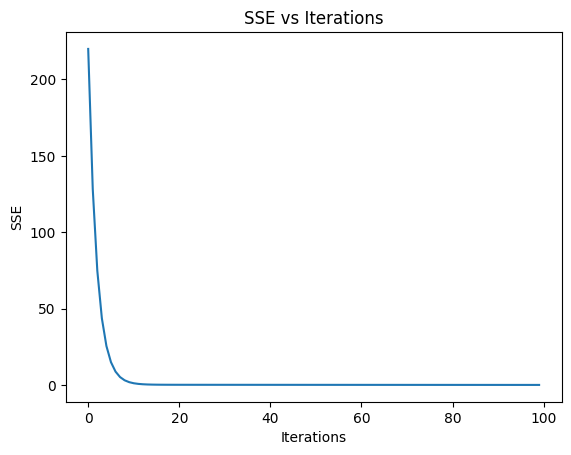

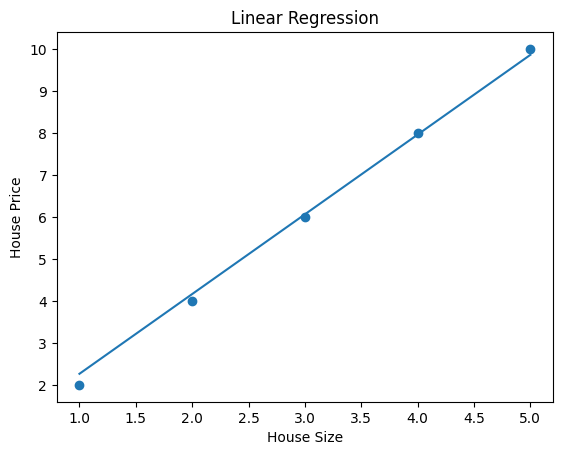

In [61]:
model_linear = LinearRegressionGD(learning_rate=0.01, n_iters=100)
model_linear.fit_linear(X, y)
y_pred_linear = model_linear.predict(X)

print("Linear Regression SSE:", model_linear.sse(y, y_pred_linear))
print("Linear Regression MSE:", model_linear.mse(y, y_pred_linear))

model_linear.plot_training(X, y)

Ridge Regression SSE: 0.29937572724838946
Ridge Regression MSE: 0.05987514544967789


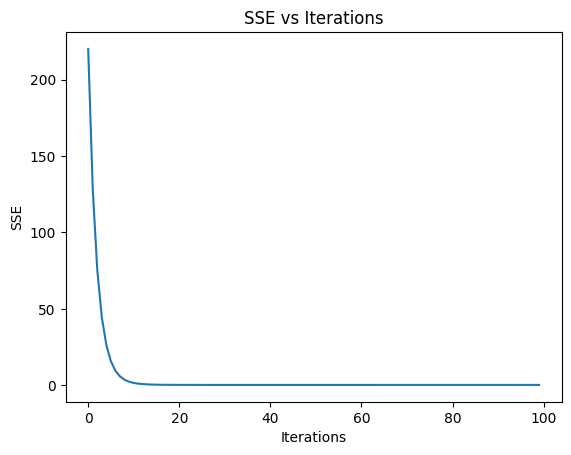

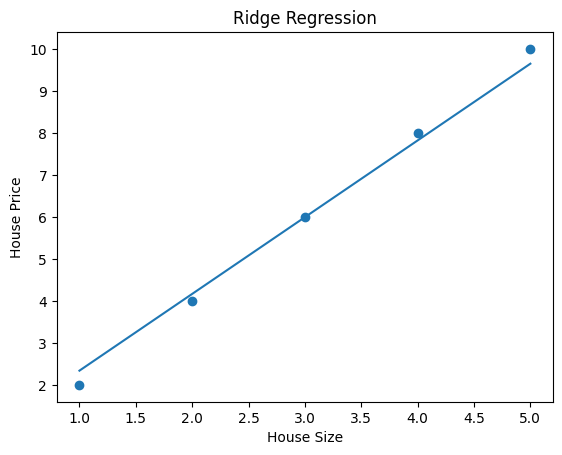

In [62]:
model_ridge = LinearRegressionGD(learning_rate=0.01, n_iters=100, alpha=1.0)
model_ridge.fit_ridge(X, y)
y_pred_ridge = model_ridge.predict(X)

print("Ridge Regression SSE:", model_ridge.sse(y, y_pred_ridge))
print("Ridge Regression MSE:", model_ridge.mse(y, y_pred_ridge))

model_ridge.plot_training(X, y)

Lasso Regression SSE: 0.12838412043260994
Lasso Regression MSE: 0.02567682408652199


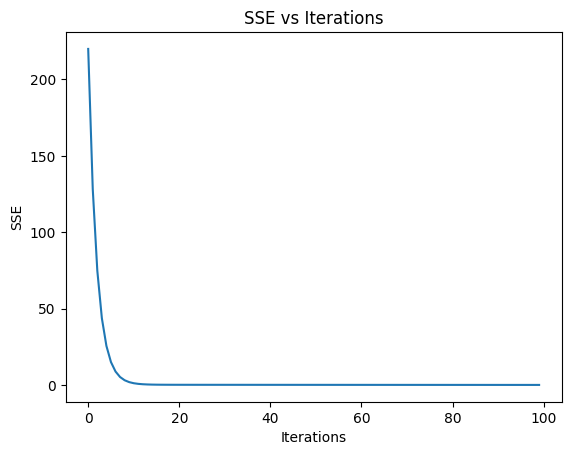

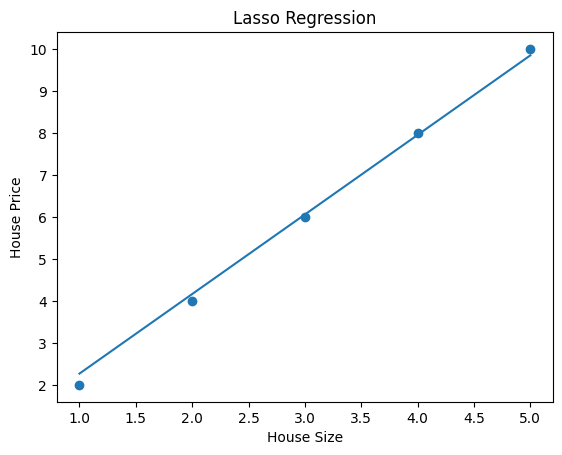

In [63]:
model_lasso = LinearRegressionGD(learning_rate=0.01, n_iters=100, alpha=0.1)
model_lasso.fit_lasso(X, y)
y_pred_lasso = model_lasso.predict(X)

print("Lasso Regression SSE:", model_lasso.sse(y, y_pred_lasso))
print("Lasso Regression MSE:", model_lasso.mse(y, y_pred_lasso))

model_lasso.plot_training(X, y)

Polynomial Regression SSE: 7.9721779569578315
Polynomial Regression MSE: 1.5944355913915662


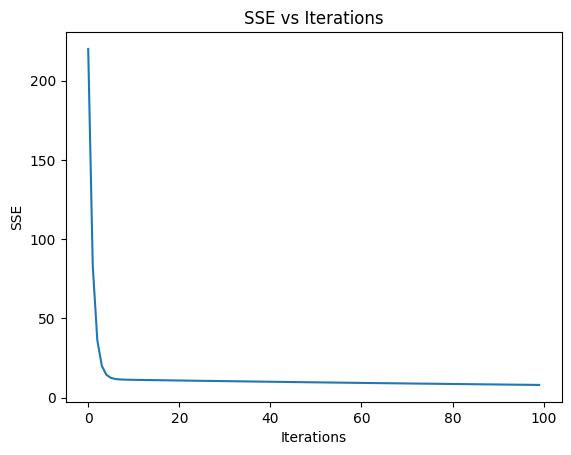

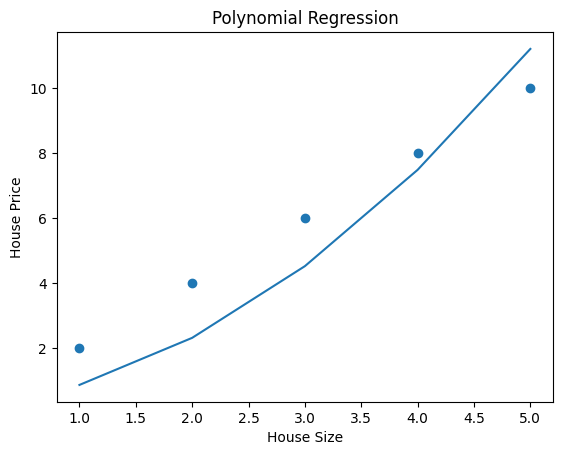

In [64]:
model_poly = LinearRegressionGD(learning_rate=0.001, n_iters=100, degree=2)
model_poly.fit_polynomial(X, y)
y_pred_poly = model_poly.predict(X)

print("Polynomial Regression SSE:", model_poly.sse(y, y_pred_poly))
print("Polynomial Regression MSE:", model_poly.mse(y, y_pred_poly))

model_poly.plot_training(X, y)